length of ats: 1
length of ats: 1
length of ats: 1
length of ats: 1
length of ats: 1
length of ats: 1
length of ats: 1
length of ats: 1
length of ats: 1
length of ats: 1
length of ats: 3
length of ats: 3
length of ats: 3
length of ats: 3
length of ats: 3
length of ats: 24


length of ats: 24
length of ats: 24
length of ats: 24
length of ats: 24
length of ats: 65
length of ats: 65
length of ats: 65
length of ats: 65
length of ats: 65


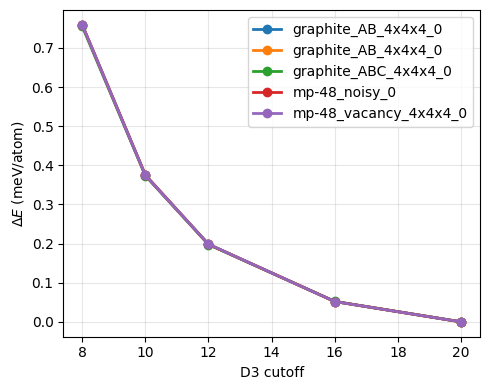

In [ ]:
import ase.io
import numpy as np
import matplotlib.pyplot as plt


# [com_inter_0, graphite_AA_4x4x4_0, graphite_AB_4x4x4_0, graphite_ABC_4x4x4_0, mp-48_noisy_0, mp-48_vacancy_4x4x4_0 ]
config_name_list = ['graphite_AB_4x4x4_0', 'graphite_AB_4x4x4_0', 'graphite_ABC_4x4x4_0', 'mp-48_noisy_0', 'mp-48_vacancy_4x4x4_0']

plt.figure(figsize=(5, 4))
for config_name in config_name_list:
    cutoff_list = [8, 10, 12, 16, 20]

    Es_list = []
    for cutoff in cutoff_list:
        ats = ase.io.read(f"/home/jerry528/fastd3/results/carbon_minimization/{config_name}/cutoff_{cutoff}A/opt.xyz", ":")
        
        print("length of ats:", len(ats))


    Es_list = []
    Nat = 0
    for cutoff in cutoff_list:
        ats = ase.io.read(f"/home/jerry528/fastd3/results/carbon_minimization/{config_name}/cutoff_{cutoff}A/minimized.xyz", "0")
        Es_list.append(ats.get_potential_energy())
        #print("length of ats:", len(ats))
        Nat = len(ats)

    x = np.array(cutoff_list)
    E = np.array(Es_list)

    # Energy difference relative to the largest system, in meV
    dE_meV = 1e3 * (E - E[-1]) / Nat

    plt.plot(
        x,
        dE_meV,
        marker="o",
        lw=2.0,
        label = config_name
    )

plt.xlabel("D3 cutoff")
plt.ylabel(r"$\Delta E$ (meV/atom)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
